# Electricity Load Forecasting: Data Preprocessing

In this notebook, we transform the raw Electricity Load Diagrams dataset into a format suitable for Machine Learning. 
We will clean the data, engineer time-based features, reshape the dataset from "wide" to "long" format, and create lag/rolling window features to capture historical consumption patterns. Finally, we will export the processed dataset.

## 1. Imports
We import the necessary libraries for data manipulation and date calculations. `dateutil.easter` is used to dynamically calculate the dates of movable Portuguese holidays.

In [1]:
import pandas as pd
import numpy as np
import datetime
from dateutil import easter
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from jenkspy import jenks_breaks


## 2. Helper Functions
Here we define the functions to calculate Portuguese national holidays and generate temporal features (like the hour of the day, day of the week, and whether a date is a weekend or holiday).

In [2]:
def get_holidays(years):
    """
    Generates a set of Portuguese national holiday dates for a list of given years.
    """
    holidays = set()
    for year in years:
        e_day = easter.easter(year)
        good_friday = e_day - datetime.timedelta(days=2)
        corpus_christi = e_day + datetime.timedelta(days=60)
        
        holidays.update([
            datetime.date(year, 1, 1),    # Ano Novo (New Year's Day)
            datetime.date(year, 4, 25),   # Dia da Liberdade (Freedom Day)
            datetime.date(year, 5, 1),    # Dia do Trabalhador (Labor Day)
            datetime.date(year, 6, 10),   # Dia de Portugal (Portugal Day)
            datetime.date(year, 8, 15),   # Assunção de Nossa Senhora (Assumption of Mary)
            datetime.date(year, 10, 5),   # Implantação da República (Republic Day)
            datetime.date(year, 11, 1),   # Dia de Todos os Santos (All Saints' Day)
            datetime.date(year, 12, 1),   # Restauração da Independência (Restoration of Independence)
            datetime.date(year, 12, 8),   # Imaculada Conceição (Immaculate Conception)
            datetime.date(year, 12, 25),  # Natal (Christmas Day)
            good_friday,                  # Sexta-feira Santa (Good Friday)
            e_day,                        # Páscoa (Easter Sunday)
            corpus_christi                # Corpo de Deus (Corpus Christi)
        ])
    return holidays

def add_temporal_features(df):
    """
    Adds time-based feature columns to the DataFrame based on the 'Date' column.
    """
    # Extract unique years from the dataset to calculate holidays dynamically
    unique_years = df['Date'].dt.year.unique()
    holidays_set = get_holidays(unique_years)
    
    # 1=Monday to 7=Sunday
    df['Weekday'] = df['Date'].dt.dayofweek + 1
    
    # 1 to 24
    df['Hour'] = df['Date'].dt.hour + 1
    
    # Format "dd-mm"
    df['DayMonth'] = df['Date'].dt.strftime('%d-%m')
    
    # True if Saturday (5) or Sunday (6)
    df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5
    
    # True if the date is in the calculated holidays set
    df['Is_Holiday'] = df['Date'].dt.date.isin(holidays_set)
    
    return df

## 3. Data Loading and Temporal Feature Engineering
We load the raw CSV. We apply the temporal features *before* melting the dataset. This is a crucial performance optimization: calculating the day of the week on 140,000 rows takes a fraction of a second, whereas doing it on 50 million rows (after melting) would take significantly longer.

In [3]:
# This cell should take less than 10 seconds to run
print("Loading data...")
df = pd.read_csv('../Datasets/Electricity Dataset.csv', sep=';', decimal=',')

# Rename timestamp column to 'Date' to keep naming consistent
df = df.rename(columns={'Unnamed: 0': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date', ascending=True).reset_index(drop=True)

# Add temporal features BEFORE melting (Huge performance boost: calculates on 140k rows instead of 51M)
print("Adding temporal features...")
df = add_temporal_features(df)

# Define the columns that should remain fixed (the time features)
# All other columns (the 370 clients) will be melted into rows
fixed_vars = ['Date', 'Weekday', 'Hour', 'DayMonth', 'Is_Weekend', 'Is_Holiday']

display(df)

Loading data...
Adding temporal features...


/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_5918/3890254079.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Weekday'] = df['Date'].dt.dayofweek + 1
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_5918/3890254079.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Hour'] = df['Date'].dt.hour + 1
/var/folders/vp/d9hp4spx22q_hf82fy0cjrl00000gn/T/ipykernel_5918/3890254079.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

,Date,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_366,MT_367,MT_368,MT_369,MT_370,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday
0,2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,1,01-01,True,True
1,2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,1,01-01,True,True
2,2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,1,01-01,True,True
3,2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,2,01-01,True,True
4,2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,2,01-01,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,...,5.851375,697.102722,176.961603,651.026393,7621.621622,3,24,31-12,False,False
140252,2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,...,9.947338,671.641791,168.614357,669.354839,6702.702703,3,24,31-12,False,False
140253,2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,...,9.362200,670.763828,153.589316,670.087977,6864.864865,3,24,31-12,False,False
140254,2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.175240,225.589226,64.685315,...,4.095963,664.618086,146.911519,646.627566,6540.540541,3,24,31-12,False,False


## 4. Wide to Long Transformation (Melting)
The raw data has 370 columns (one for each client). To train a model effectively and engineer lag features properly, we "melt" the dataset so that each row represents a single observation for a single client at a specific time.

We also strictly downcast our numeric and categorical columns to save RAM.

In [4]:
# This cell should take less than 20 seconds to run
df_long = pd.melt(
    df, 
    id_vars=fixed_vars,             # The columns to keep fixed
    var_name='ClientID',            # Name of the new column storing the client IDs (e.g., 'MT_001')
    value_name='Consumption'        # Name of the new column storing the actual kW values
)

# Memory optimization: Downcast the target variable to save RAM.
df_long['Consumption'] = df_long['Consumption'].astype(np.float32)

# Memory optimization: Convert ClientID to a category type (saves massive amounts of memory for repeated strings)
df_long['ClientID'] = df_long['ClientID'].astype('category')

display(df_long)


,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption
0,2011-01-01 00:15:00,6,1,01-01,True,True,MT_001,0.000000
1,2011-01-01 00:30:00,6,1,01-01,True,True,MT_001,0.000000
2,2011-01-01 00:45:00,6,1,01-01,True,True,MT_001,0.000000
3,2011-01-01 01:00:00,6,2,01-01,True,True,MT_001,0.000000
4,2011-01-01 01:15:00,6,2,01-01,True,True,MT_001,0.000000
...,...,...,...,...,...,...,...,...
51894715,2014-12-31 23:00:00,3,24,31-12,False,False,MT_370,7621.621582
51894716,2014-12-31 23:15:00,3,24,31-12,False,False,MT_370,6702.702637
51894717,2014-12-31 23:30:00,3,24,31-12,False,False,MT_370,6864.864746
51894718,2014-12-31 23:45:00,3,24,31-12,False,False,MT_370,6540.540527


## 5 Client Segmentation
We're ranking clients by their average consumption then splitting them into 3 gorups: light, medium, heavy. Since the data is heavily right-skewed we first log transformed the average consumptions then used Jenks algorithm to find the split that minimizes within-group variance and maximizes between-group variance. 

Light consumers:  below 45.29 kW average
Medium consumers: 45.29 to 313.96 kW average
Heavy consumers:  above 313.96 kW average

Category distribution:
Consumer_Category
Heavy      92
Light      99
Medium    179
Name: ClientID, dtype: int64


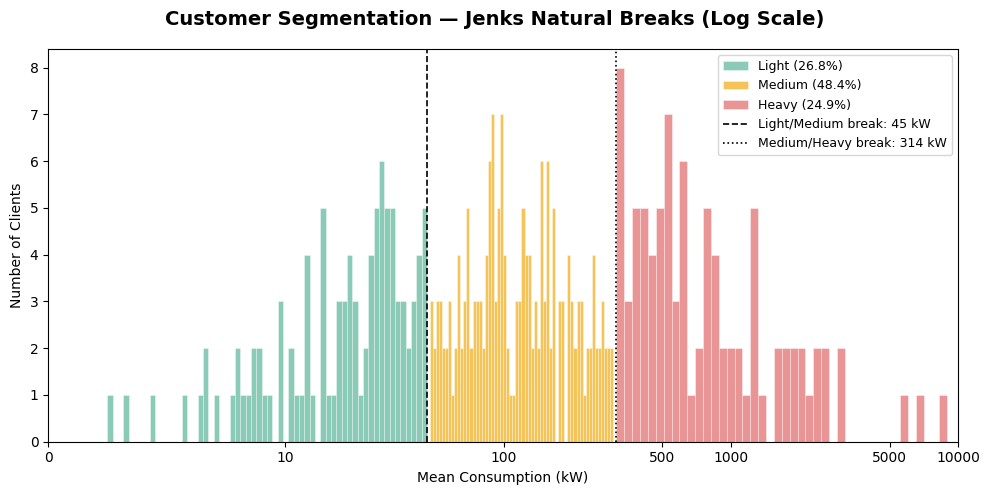

In [5]:
# Client's mean consumption
client_means = df_long.groupby('ClientID', observed=True)['Consumption'].mean()

# Compute log means for each client to use in Jenks natural breaks
log_means = np.log1p(client_means)
breaks = jenks_breaks(log_means.values, n_classes=3)

# Convert breaks back to original kW scale for interpretability
light_threshold_log = breaks[1]
heavy_threshold_log = breaks[2]
light_threshold = np.expm1(breaks[1])
heavy_threshold = np.expm1(breaks[2])

print(f"Light consumers:  below {light_threshold:.2f} kW average")
print(f"Medium consumers: {light_threshold:.2f} to {heavy_threshold:.2f} kW average")
print(f"Heavy consumers:  above {heavy_threshold:.2f} kW average")

def categorize_client(mean_val):
    log_val = np.log1p(mean_val)
    if log_val <= light_threshold_log:
        return 'Light'
    elif log_val <= heavy_threshold_log:
        return 'Medium'
    else:
        return 'Heavy'

client_categories = client_means.apply(categorize_client).rename('Consumer_Category')
df_long = df_long.merge(client_categories, on='ClientID', how='left')
df_long['Consumer_Category'] = df_long['Consumer_Category'].astype('category')

print(f"\nCategory distribution:")
print(df_long.groupby('Consumer_Category', observed=True)['ClientID'].nunique())

# --- Percentages ---
cat_labels = client_categories.reset_index()
cat_labels.columns = ['ClientID', 'Consumer_Category']
plot_df = client_means.reset_index()
plot_df.columns = ['ClientID', 'MeanConsumption']
plot_df = plot_df.merge(cat_labels, on='ClientID').sort_values('MeanConsumption').reset_index(drop=True)

total = len(plot_df)
pcts = plot_df['Consumer_Category'].value_counts(normalize=True) * 100

# --- Plot ---
colors = {'Light': '#4CAF93', 'Medium': '#F0A500', 'Heavy': '#E05C5C'}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Customer Segmentation — Jenks Natural Breaks (Log Scale)', fontsize=14, fontweight='bold')

# Histogram with log-transformed x-axis
for label, color in colors.items():
    vals = np.log1p(plot_df.loc[plot_df['Consumer_Category'] == label, 'MeanConsumption'])
    ax.hist(vals, bins=60, color=color, alpha=0.65, label=f"{label} ({pcts[label]:.1f}%)",
            edgecolor='white', linewidth=0.4)

ax.axvline(light_threshold_log, color='black', linestyle='--', linewidth=1.2, 
           label=f'Light/Medium break: {light_threshold:.0f} kW')
ax.axvline(heavy_threshold_log, color='black', linestyle=':', linewidth=1.2, 
           label=f'Medium/Heavy break: {heavy_threshold:.0f} kW')

tick_vals_kw = [0, 10, 100, 500, 1000, 5000, 10000]
tick_vals_log = np.log1p(tick_vals_kw)
ax.set_xticks(tick_vals_log)
ax.set_xticklabels([str(v) for v in tick_vals_kw])
ax.set_xlim(np.log1p(0), np.log1p(10000))

ax.set_xlabel('Mean Consumption (kW)')
ax.set_ylabel('Number of Clients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('jenks_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 National Weather
Since we don't know where each client is located, we built a national average temperature as a proxy signal.
Rather than a simple average of 4 cities, we weight each city by its population: Lisbon (547k), Porto (237k), Faro (64k), Évora (56k). 

From that weighted temperature we also derive two extra columns:

- HDH (Heating Degree Hours): how many degrees below 18°C it is. When this is high, people are heating their homes, so consumption goes up. 

- CDH (Cooling Degree Hours): how many degrees above 18°C it is. When this is high, people are running air conditioning, so consumption goes up. 

18°C is the standard comfort threshold used in energy modeling. 

In [6]:
# 2011 population estimates (thousands) for weighting
# Source: INE Portugal
cities = {
    "Lisbon": {"lat": 38.72, "lon": -9.14,  "population": 547},
    "Porto":  {"lat": 41.15, "lon": -8.61,  "population": 237},
    "Faro":   {"lat": 37.02, "lon": -7.93,  "population": 64},
    "Evora":  {"lat": 38.57, "lon": -7.91,  "population": 56},
}

total_population = sum(c["population"] for c in cities.values())

all_temps = []

for city, info in cities.items():
    print(f"  Fetching weather for {city}...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   info["lat"],
        "longitude":  info["lon"],
        "start_date": "2011-01-01",
        "end_date":   "2015-01-01",
        "hourly":     "temperature_2m",
        "timezone":   "Europe/Lisbon",
    }
    response = requests.get(url, params=params)
    data = response.json()

    weight = info["population"] / total_population

    temp_df = pd.DataFrame({
        "Date":   pd.to_datetime(data["hourly"]["time"]),
        "temp":   data["hourly"]["temperature_2m"],
    })
    temp_df["weighted_temp"] = temp_df["temp"] * weight
    all_temps.append(temp_df[["Date", "weighted_temp"]])

# Sum weighted temperatures across all cities
weather_df = all_temps[0].copy()
weather_df["Temp_National_Avg"] = sum(df["weighted_temp"] for df in all_temps)
weather_df = weather_df[["Date", "Temp_National_Avg"]]

# Heating/Cooling Degree Hours (base 18°C is standard for energy modeling)
weather_df["HDH"] = (18 - weather_df["Temp_National_Avg"]).clip(lower=0).astype(np.float32)
weather_df["CDH"] = (weather_df["Temp_National_Avg"] - 18).clip(lower=0).astype(np.float32)
weather_df["Temp_National_Avg"] = weather_df["Temp_National_Avg"].astype(np.float32)

# Floor electricity timestamps to the hour to match hourly weather data
df_long["Date_Hour"] = df_long["Date"].dt.floor("h")
weather_df["Date_Hour"] = weather_df["Date"]

df_long = df_long.merge(
    weather_df[["Date_Hour", "Temp_National_Avg", "HDH", "CDH"]],
    on="Date_Hour",
    how="left"
).drop(columns=["Date_Hour"])

print("Weather merge complete!")

display(df_long)

  Fetching weather for Lisbon...
  Fetching weather for Porto...
  Fetching weather for Faro...
  Fetching weather for Evora...
Weather merge complete!


,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption,Consumer_Category,Temp_National_Avg,HDH,CDH
0,2011-01-01 00:15:00,6,1,01-01,True,True,MT_001,0.000000,Light,11.511062,6.488938,0.0
1,2011-01-01 00:30:00,6,1,01-01,True,True,MT_001,0.000000,Light,11.511062,6.488938,0.0
2,2011-01-01 00:45:00,6,1,01-01,True,True,MT_001,0.000000,Light,11.511062,6.488938,0.0
3,2011-01-01 01:00:00,6,2,01-01,True,True,MT_001,0.000000,Light,11.352433,6.647566,0.0
4,2011-01-01 01:15:00,6,2,01-01,True,True,MT_001,0.000000,Light,11.352433,6.647566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
51894715,2014-12-31 23:00:00,3,24,31-12,False,False,MT_370,7621.621582,Heavy,6.770464,11.229535,0.0
51894716,2014-12-31 23:15:00,3,24,31-12,False,False,MT_370,6702.702637,Heavy,6.770464,11.229535,0.0
51894717,2014-12-31 23:30:00,3,24,31-12,False,False,MT_370,6864.864746,Heavy,6.770464,11.229535,0.0
51894718,2014-12-31 23:45:00,3,24,31-12,False,False,MT_370,6540.540527,Heavy,6.770464,11.229535,0.0


## 7 Trimming Leading Zeros

Many clients joined the grid after 2011. This means their data starts with thousands of zeros. 
We identify the first active timestamp for each client and remove the preceding inactive period to ensure our averages and models aren't skewed by "pre-activation" zeros.

In [7]:
# This cell should take around 10 seconds to run
print("Trimming leading zeros (finding actual start date for each client)...")

# Identify the first timestamp with consumption > 0 for each client
start_dates = df_long[df_long['Consumption'] > 0].groupby('ClientID', observed=True)['Date'].min().reset_index()
start_dates.columns = ['ClientID', 'StartDate']

# Merge the start dates back into the main dataframe
df_long = df_long.merge(start_dates, on='ClientID')

# Keep only the rows where Date is greater than or equal to the StartDate
df_long = df_long[df_long['Date'] >= df_long['StartDate']].copy()

# Clean up the helper column
df_long = df_long.drop(columns=['StartDate'])

print(f"Trimmed inactive periods. Remaining rows: {len(df_long)}")

display(df_long)

Trimming leading zeros (finding actual start date for each client)...
Trimmed inactive periods. Remaining rows: 41936458


,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption,Consumer_Category,Temp_National_Avg,HDH,CDH
35040,2012-01-01 00:15:00,7,1,01-01,True,True,MT_001,3.807106,Light,10.641482,7.358518,0.0
35041,2012-01-01 00:30:00,7,1,01-01,True,True,MT_001,5.076142,Light,10.641482,7.358518,0.0
35042,2012-01-01 00:45:00,7,1,01-01,True,True,MT_001,3.807106,Light,10.641482,7.358518,0.0
35043,2012-01-01 01:00:00,7,2,01-01,True,True,MT_001,3.807106,Light,10.481637,7.518363,0.0
35044,2012-01-01 01:15:00,7,2,01-01,True,True,MT_001,5.076142,Light,10.481637,7.518363,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
51894715,2014-12-31 23:00:00,3,24,31-12,False,False,MT_370,7621.621582,Heavy,6.770464,11.229535,0.0
51894716,2014-12-31 23:15:00,3,24,31-12,False,False,MT_370,6702.702637,Heavy,6.770464,11.229535,0.0
51894717,2014-12-31 23:30:00,3,24,31-12,False,False,MT_370,6864.864746,Heavy,6.770464,11.229535,0.0
51894718,2014-12-31 23:45:00,3,24,31-12,False,False,MT_370,6540.540527,Heavy,6.770464,11.229535,0.0


## 8. Grouped Lag and Rolling Features
To forecast future consumption, the model needs to know recent past consumption. We calculate what the client consumed 15 minutes ago (Lag_15min), 24 hours ago (Lag_24h), and their average consumption over the last 4 hours (Rolling_Mean_4h). 

**Critical step:** We must sort the data chronologically per client before calculating these shifts to ensure data integrity.

In [8]:
# This cell should take less than 20 seconds to run

# Sorting the Data chronologically per client before shifting
print("Sorting data for lag calculations...")
df_long = df_long.sort_values(by=['ClientID', 'Date']).reset_index(drop=True)

print("Calculating Lags and Rolling Windows...")
# Create Lag Features Grouped by Client
# shift(1) = 1 step back (15 minutes ago)
# shift(96) = 96 steps back (24 hours ago, since 96 * 15 min = 24h)
df_long['Lag_15min'] = df_long.groupby('ClientID', observed=True)['Consumption'].shift(1).astype(np.float32)
df_long['Lag_24h'] = df_long.groupby('ClientID', observed=True)['Consumption'].shift(96).astype(np.float32)

# Create Rolling Window Features Grouped by Client
# Calculate the moving average of the past 4 hours (16 intervals of 15 mins).
df_long['Rolling_Mean_4h'] = df_long.groupby('ClientID', observed=True)['Consumption'].transform(
    lambda x: x.rolling(window=16).mean()
).astype(np.float32)

# Optional: Drop rows with NaN values generated by the shift/rolling operations 
# (The first 24 hours of data for each client will have NaNs due to the 24h lag)
print("Dropping NaNs...")
df_long = df_long.dropna().reset_index(drop=True)

print("Feature Engineering Complete!")
display(df_long)

Sorting data for lag calculations...
Calculating Lags and Rolling Windows...
Dropping NaNs...
Feature Engineering Complete!


,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption,Consumer_Category,Temp_National_Avg,HDH,CDH,Lag_15min,Lag_24h,Rolling_Mean_4h
0,2012-01-02 00:15:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,3.807106,11.976522
1,2012-01-02 00:30:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,5.076142,11.976522
2,2012-01-02 00:45:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,3.807106,11.817893
3,2012-01-02 01:00:00,1,2,02-01,False,False,MT_001,3.807106,Light,12.715265,5.284735,0.0,3.807106,3.807106,10.945432
4,2012-01-02 01:15:00,1,2,02-01,False,False,MT_001,3.807106,Light,12.715265,5.284735,0.0,3.807106,5.076142,9.993655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41900933,2014-12-31 23:00:00,3,24,31-12,False,False,MT_370,7621.621582,Heavy,6.770464,11.229535,0.0,7189.188965,18378.378906,8192.567383
41900934,2014-12-31 23:15:00,3,24,31-12,False,False,MT_370,6702.702637,Heavy,6.770464,11.229535,0.0,7621.621582,17351.351562,8040.540527
41900935,2014-12-31 23:30:00,3,24,31-12,False,False,MT_370,6864.864746,Heavy,6.770464,11.229535,0.0,6702.702637,18864.865234,7929.054199
41900936,2014-12-31 23:45:00,3,24,31-12,False,False,MT_370,6540.540527,Heavy,6.770464,11.229535,0.0,6864.864746,17621.621094,7804.054199


## 9. Exporting the Processed Data
We save the result as a Parquet file. Parquet preserves our `float32` and `category` memory optimizations, drastically reducing both file size and load times for the modeling phase compared to a standard CSV.

In [9]:
display(df_long)

,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption,Consumer_Category,Temp_National_Avg,HDH,CDH,Lag_15min,Lag_24h,Rolling_Mean_4h
0,2012-01-02 00:15:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,3.807106,11.976522
1,2012-01-02 00:30:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,5.076142,11.976522
2,2012-01-02 00:45:00,1,1,02-01,False,False,MT_001,3.807106,Light,12.524778,5.475221,0.0,3.807106,3.807106,11.817893
3,2012-01-02 01:00:00,1,2,02-01,False,False,MT_001,3.807106,Light,12.715265,5.284735,0.0,3.807106,3.807106,10.945432
4,2012-01-02 01:15:00,1,2,02-01,False,False,MT_001,3.807106,Light,12.715265,5.284735,0.0,3.807106,5.076142,9.993655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41900933,2014-12-31 23:00:00,3,24,31-12,False,False,MT_370,7621.621582,Heavy,6.770464,11.229535,0.0,7189.188965,18378.378906,8192.567383
41900934,2014-12-31 23:15:00,3,24,31-12,False,False,MT_370,6702.702637,Heavy,6.770464,11.229535,0.0,7621.621582,17351.351562,8040.540527
41900935,2014-12-31 23:30:00,3,24,31-12,False,False,MT_370,6864.864746,Heavy,6.770464,11.229535,0.0,6702.702637,18864.865234,7929.054199
41900936,2014-12-31 23:45:00,3,24,31-12,False,False,MT_370,6540.540527,Heavy,6.770464,11.229535,0.0,6864.864746,17621.621094,7804.054199


In [10]:
# This cell should take less than 30 seconds to run

print("Saving to Parquet format...")
df_long.to_parquet('../Datasets/processed_electricity_data.parquet', index=False)
print("Preprocessing complete! File saved as '../Datasets/processed_electricity_data.parquet'")

Saving to Parquet format...
Preprocessing complete! File saved as '../Datasets/processed_electricity_data.parquet'
